In [12]:
import dlib
import cv2
import os
import re
import json
from pylab import *
from PIL import Image, ImageChops, ImageEnhance
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sn
import pandas as pd
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix,f1_score,classification_report
from tensorflow.keras.models import load_model
from tqdm import tqdm

In [13]:
input_shape = (224, 224, 3)
data_dir = '/Users/ardrapadmakumar/Desktop/deepfake/deepfake/op'

real_data = []
fake_data = []

for f in os.listdir(data_dir+'/real'):
    if f.endswith('.png'):
        real_data.append(f)
    
for f in os.listdir(data_dir+'/fake'):
    if f.endswith('.png'):
        fake_data.append(f)    
X = []

Y = []

for img in real_data:
    img=load_img(data_dir+'/real/'+img) 
    img=tf.image.resize(img,[224,224])
    X.append(img_to_array(img) / 255.0) 
    Y.append(1)
for img in fake_data:
    img=load_img(data_dir+'/fake/'+img) 
    img=tf.image.resize(img,[224,224])
    X.append(img_to_array(img) / 255.0)
    Y.append(0)

Y_val_org = Y

X = np.array(X)
Y = to_categorical(Y, 2)

X = X.reshape(-1, 224, 224, 3)

X_train, X_val, Y_train, Y_val = train_test_split(X, Y, test_size = 0.25, random_state=5)

In [14]:
from tensorflow.keras.applications import InceptionResNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

base_model = InceptionResNetV2(
    include_top=False,
    weights='imagenet',
    input_shape=input_shape
)

base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
output = Dense(2, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_406 (Conv2D) │ (None, 111, 111,  │        864 │ input_layer_2[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 111, 111,  │         96 │ conv2d_406[0][0]  │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_406      │ (None, 111, 111,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_407 (Conv2D) │ (None, 109, 109,  │      9,216 │ activation_406[0… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 109, 109,  │         96 │ conv2d_407[0][0]  │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_407      │ (None, 109, 109,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_408 (Conv2D) │ (None, 109, 109,  │     18,432 │ activation_407[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 109, 109,  │        192 │ conv2d_408[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_408      │ (None, 109, 109,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_8     │ (None, 54, 54,    │          0 │ activation_408[0… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_409 (Conv2D) │ (None, 54, 54,    │      5,120 │ max_pooling2d_8[… │
│                     │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 54, 54,    │        240 │ conv2d_409[0][0]  │
│ (BatchNormalizatio… │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_409      │ (None, 54, 54,    │          0 │ batch_normalizat… │
│ (Activation)        │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_410 (Conv2D) │ (None, 52, 52,    │    138,240 │ activation_409[0… │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 52, 52,    │        576 │ conv2d_410[0][0]  │
│ (BatchNormalizatio… │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_410      │ (None, 52, 52,    │          0 │ batch_normalizat

 Total params: 54,339,810 (207.29 MB)

 Trainable params: 3,074 (12.01 KB)

 Non-trainable params: 54,336,736 (207.28 MB)

In [15]:
early_stopping = EarlyStopping(monitor='val_loss',
                               min_delta=0,
                               patience=8,
                               verbose=0, mode='auto')
EPOCHS = 100
BATCH_SIZE = 6
history = model.fit(X_train, Y_train, batch_size = BATCH_SIZE, epochs = EPOCHS, validation_data = (X_val, Y_val), verbose = 1)

Epoch 1/100
209/209 ━━━━━━━━━━━━━━━━━━━━ 96s 419ms/step - accuracy: 0.7098 - loss: 0.6125 - val_accuracy: 0.7321 - val_loss: 0.5762
Epoch 2/100
209/209 ━━━━━━━━━━━━━━━━━━━━ 93s 446ms/step - accuracy: 0.7506 - loss: 0.5462 - val_accuracy: 0.7416 - val_loss: 0.5288
Epoch 3/100
209/209 ━━━━━━━━━━━━━━━━━━━━ 96s 459ms/step - accuracy: 0.7834 - loss: 0.4986 - val_accuracy: 0.7895 - val_loss: 0.4887
Epoch 4/100
209/209 ━━━━━━━━━━━━━━━━━━━━ 105s 505ms/step - accuracy: 0.8265 - loss: 0.4578 - val_accuracy: 0.8373 - val_loss: 0.4532
Epoch 5/100
209/209 ━━━━━━━━━━━━━━━━━━━━ 108s 518ms/step - accuracy: 0.8673 - loss: 0.4220 - val_accuracy: 0.8852 - val_loss: 0.4218
Epoch 6/100
209/209 ━━━━━━━━━━━━━━━━━━━━ 104s 500ms/step - accuracy: 0.8953 - loss: 0.3909 - val_accuracy: 0.9115 - val_loss: 0.3945
Epoch 7/100
209/209 ━━━━━━━━━━━━━━━━━━━━ 108s 518ms/step - accuracy: 0.9225 - loss: 0.3635 - val_accuracy: 0.9211 - val_loss: 0.3698
Epoch 8/100
209/209 ━━━━━━━━━━━━━━━━━━━━ 114s 548ms/step - accuracy: 0.9

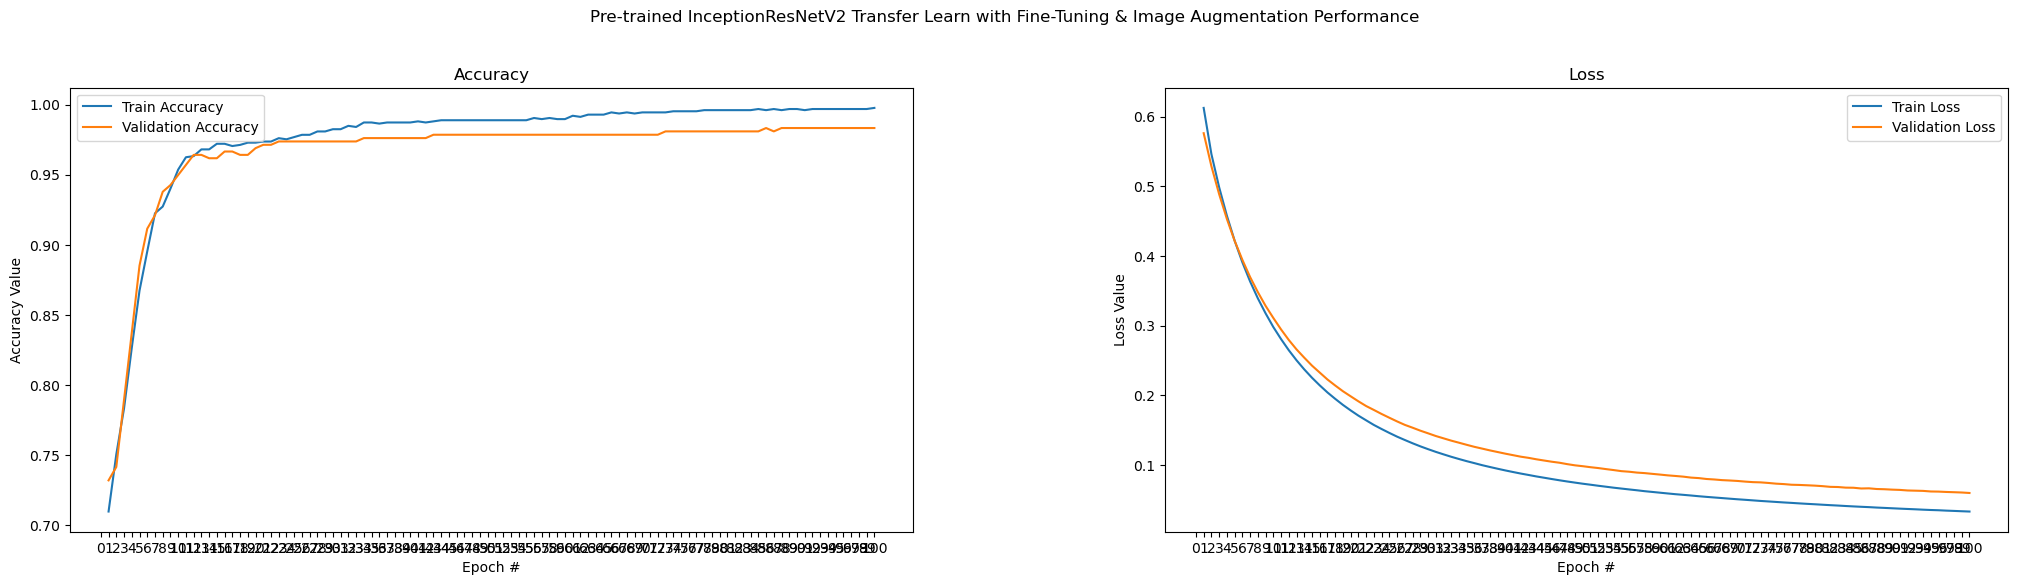

In [16]:
f, (ax1, ax2) = plt.subplots(1, 2, figsize=(25, 6))
t = f.suptitle('Pre-trained InceptionResNetV2 Transfer Learn with Fine-Tuning & Image Augmentation Performance ', fontsize=12)
f.subplots_adjust(top=0.85, wspace=0.3)

epoch_list = list(range(1,EPOCHS+1))
ax1.plot(epoch_list, history.history['accuracy'], label='Train Accuracy')
ax1.plot(epoch_list, history.history['val_accuracy'], label='Validation Accuracy')
ax1.set_xticks(np.arange(0, EPOCHS+1, 1))
ax1.set_ylabel('Accuracy Value')
ax1.set_xlabel('Epoch #')
ax1.set_title('Accuracy')
l1 = ax1.legend(loc="best")

ax2.plot(epoch_list, history.history['loss'], label='Train Loss')
ax2.plot(epoch_list, history.history['val_loss'], label='Validation Loss')
ax2.set_xticks(np.arange(0, EPOCHS+1, 1))
ax2.set_ylabel('Loss Value')
ax2.set_xlabel('Epoch #')
ax2.set_title('Loss')
l2 = ax2.legend(loc="best")

# Saving the Model for future use

In [17]:
model.save('model.h5')

In [18]:
model.save('mymodel.keras')